In [1]:
import numpy as np
import os
import re

In [ ]:
region_map = {'UKNegatives': 'UK',
              'USA': 'USA',
              'Russia': 'Russia',
              'Russia2': 'Russia',
              'Russia3': 'Russia',
              'Karoo': 'Karoo',
              'Brazil': 'Brazil',
              'Australia': 'Australia',
              'France': 'France',
              'Texas': 'USA',
              'UKTraining': 'Somerset',
              'EastQuantock': 'Somerset',
              'UKQuantock': 'Somerset',}

In [ ]:
output_dir = '/Users/willmcmahon/Documents/PhD/scd-detection/data/PostIRP/dataset/'

In [ ]:
pattern = r'g\d{4}_'

for dir in ['/Users/willmcmahon/Downloads/Tiles 2', '/Users/willmcmahon/Downloads/Tiles 3']:
    for root, dirs, files in os.walk(dir):
        for file in files:
            if file.endswith('.npz'):
                data = np.load(os.path.join(root, file))
                resolution = data['res']
                positive = 0 if data['scd_pixel_fraction'] == 0 else 1
                positive_str = 'positive' if positive == 1 else 'negative'
                region = os.path.basename(os.path.dirname(os.path.join(root, file)))  # parent directory name of the specific file
                region = region_map[region]

                if 'Copy of' in file:
                    file = file.replace('Copy of ', '')

                file = file.replace('pos_', '')
                file = file.replace('neg_', '')

                # find and remove group indicator (g0001, g0002, etc.)
                file = re.sub(pattern, '', file)

                bounds = file.strip('.npz').split('_')[-4:] # last 4 in path are bounds
                for i in range(len(bounds)):
                    try:
                        bounds[i] = int(bounds[i])
                    except ValueError:
                        print(f"Could not convert {bounds[i]} to int for file {file}")


                name = f"{region}_{positive_str}_{file}"

                np.savez_compressed(os.path.join(output_dir, name),
                        image=data['image'], 
                        layer_names=data['layer_names'],
                        res=resolution,
                        labels = data['labels'],
                        scd_pixel_fraction=data['scd_pixel_fraction'],
                        positive=positive,
                        region=region,
                        bounds = tuple(bounds))
            

# Dataset Analysis


/opt/anaconda3/envs/IRP311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


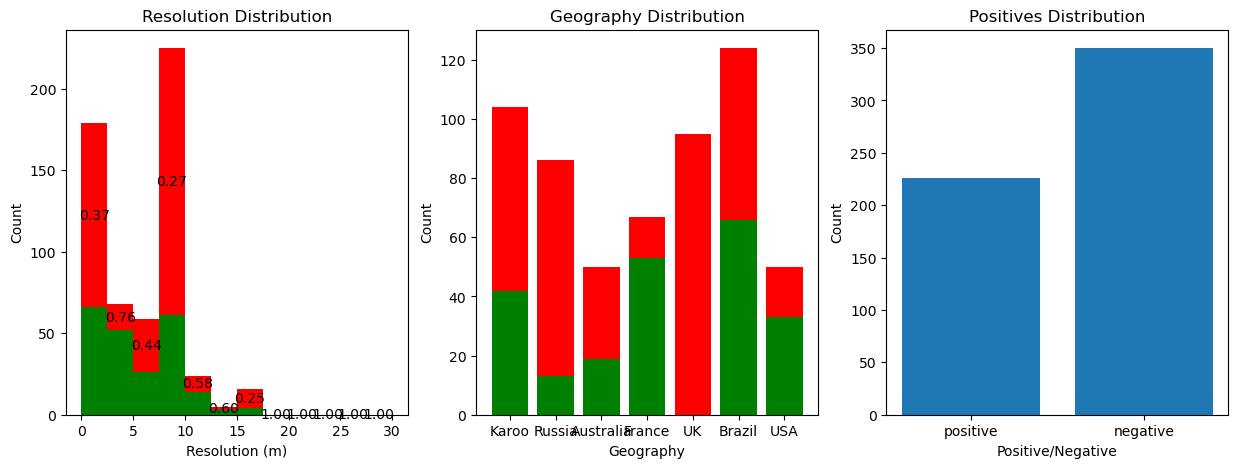

In [1]:
import sys
from pathlib import Path
CODE_DIR = Path("../../../code").resolve()
sys.path.insert(0, str(CODE_DIR))

from loaders.dataset import DatasetWrapper, DatasetRefiner

dset = DatasetWrapper('/Users/willmcmahon/Documents/PhD/scd-detection/data/PostIRP/dataset/')
trainset, testset = dset.generate_dataset(test_region='Somerset')

dset.plot_distribution()


# refine dataset

In [ ]:
refiner = DatasetRefiner('/Users/willmcmahon/Documents/PhD/scd-detection/data/PostIRP/dataset/', 'USA')

In [ ]:
refiner.refine()

In [ ]:
refiner.tiles